# Search algorithms

### Fully connected graph

For a start, we'll implement the search on fully connected graph, to reproduce Grover's result.

In [44]:
import numpy as np                          # linear algebra

graph_size = 256

x = np.ones(graph_size, dtype=np.complex128)/np.sqrt(graph_size)  # position vector

init_state = x

laplace_connected = ((graph_size) * np.identity(graph_size)) - np.ones(graph_size, dtype=np.complex128)

marked = np.zeros((graph_size, graph_size), dtype=np.complex128)
marked[0, 0] = 1

target = np.zeros(graph_size, dtype=np.complex128)
target[0] = 1

def hamiltonian_connected(gamma) : return gamma*laplace_connected - marked 

In [ ]:
from scipy.linalg import expm

#def Evol_vector(t, state, hamiltonian):
#    return expm(-1j * hamiltonian * t) @ state

def Success_prob_conn(gamma, t):
    return abs(init_state.conj().T @ expm(-1j * hamiltonian_connected(gamma) * t) @ target)**2

def Failure_prob_conn(params):
    gamma, t = params
    return 1 - Success_prob_conn(gamma, t)

In [ ]:
from scipy.optimize import minimize

x0 = [1/graph_size + 0.001, np.pi/2*np.sqrt(graph_size) + 0.1]
bnds = ((0, 2), (0, graph_size))
sol = minimize(Failure_prob_conn, x0, bounds=bnds)

In [144]:
x0

[0.00490625, np.float64(25.232741228718346)]

In [145]:
[1/graph_size, np.pi/2*np.sqrt(graph_size)]

[0.00390625, np.float64(25.132741228718345)]

In [146]:
opt_t = sol.x[1]

In [147]:
sol

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.840941596334383
        x: [ 5.189e-03  2.523e+01]
      nit: 6
      jac: [ 1.577e-02 -1.053e-02]
     nfev: 51
     njev: 17
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

In [ ]:
def gettimes(t_opt, size):
    t_current = np.zeros(size)

    for i in range(size):
        t_current[i] = t_opt / size * 2 * i

    return t_current

def probs_t(gamma, t_opt, size):
    probs = np.zeros(size)

    for i in range(size):
        t_current = t_opt / size * 2 * i
        probs[i] = Success_prob_conn(gamma, t_current)

    return probs

graph_probs = probs_t(1/graph_size, np.pi/2*np.sqrt(graph_size), 100)
times = gettimes(np.pi/2*np.sqrt(graph_size), 100)

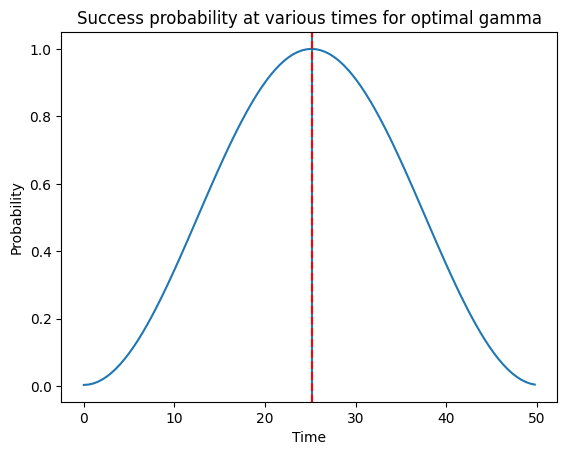

In [148]:
import matplotlib.pyplot as plt

plt.plot(times, graph_probs)

plt.xlabel("Time")
plt.ylabel("Probability")
plt.title('Success probability at various times for optimal gamma')

plt.axvline(x= np.pi/2*np.sqrt(graph_size))
plt.axvline(x = opt_t, color='r', linestyle='--')

### Bipartite graph

In [173]:
import numpy as np                          # linear algebra

nodes1 = 512
nodes2 = 256

graph_size = nodes1 + nodes2

x = np.ones(graph_size, dtype=np.complex128)/np.sqrt(graph_size)  # position vector

init_state = x

laplace_nodes1 = nodes2 * np.identity(nodes1)
laplace_nodes2 = nodes1 * np.identity(nodes2)

laplace_bipartite = np.zeros((graph_size, graph_size), dtype=np.complex128)

for i in range(graph_size):
    for j in range(graph_size):
        if i < nodes1:
            if i == j: laplace_bipartite[i, j] = nodes2
            if j > nodes1:
                laplace_bipartite[i, j] = -1
        else:
            if i == j: laplace_bipartite[i, j] = nodes1
            if j < nodes1:
                laplace_bipartite[i, j] = -1

marked = np.zeros((graph_size, graph_size), dtype=np.complex128)

marked1 = 3
marked2 = 5

for i in range(marked1):
    marked[i, i] = 1

for i in range(marked2):
    marked[i+nodes1, i+nodes1]= 1


def hamiltonian_bipartite(gamma) : return gamma*laplace_bipartite - marked 

In [175]:
a = np.zeros(graph_size, dtype=np.complex128)

for i in range(marked1):
    a[i] = 1

a = a/np.sqrt(marked1)

gamma_a = 1/nodes2
t_a = np.pi/2*np.sqrt(graph_size/marked1)

b = np.zeros(graph_size, dtype=np.complex128)

for i in range(marked2):
    b[i+nodes1]= 1

b = b/np.sqrt(marked2)

gamma_b = 1/nodes1
t_b = np.pi/2*np.sqrt(graph_size/marked2)

In [176]:
from scipy.linalg import expm

#def Evol_vector(t, state, hamiltonian):
#    return expm(-1j * hamiltonian * t) @ state

def Success_prob_bi_l(gamma, t, target):
    return abs(init_state.conj().T @ expm(-1j * hamiltonian_bipartite(gamma) * t) @ target)**2

def Failure_prob_bi_l(params):
    gamma, t, target = params
    return 1 - Success_prob_bi_l(gamma, t, target)

In [ ]:
from scipy.optimize import minimize

x0 = [1/graph_size + 0.001, np.pi/2*np.sqrt(graph_size) + 0.1]
bnds = ((0, 2), (0, graph_size))
sol = minimize(Failure_prob_bi_l, x0, bounds=bnds)

TypeError: Failure_prob_bi_l() got an unexpected keyword argument 'target'

In [177]:
def gettimes(t_opt, size):
    t_current = np.zeros(size)

    for i in range(size):
        t_current[i] = t_opt / size * 2 * i

    return t_current

def probs_t(gamma, t_opt, size, target):
    probs = np.zeros(size)

    for i in range(size):
        t_current = t_opt / size * 2 * i
        probs[i] = Success_prob_bi_l(gamma, t_current, target)

    return probs

graph_probs = probs_t(gamma_a, t_a, 100, a)
times = gettimes(t_a, 100)

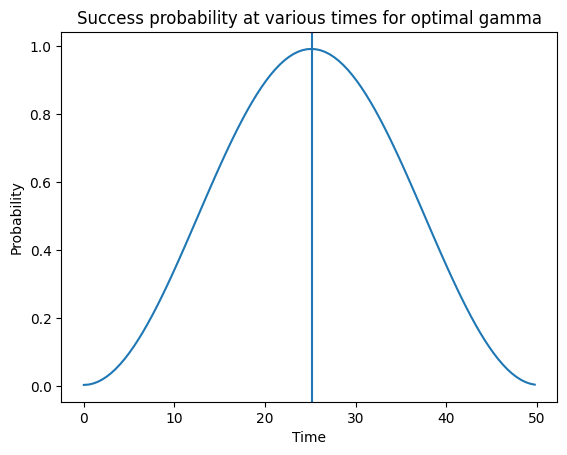

In [178]:
import matplotlib.pyplot as plt

plt.plot(times, graph_probs)

plt.xlabel("Time")
plt.ylabel("Probability")
plt.title('Success probability at various times for optimal gamma')

plt.axvline(x= t_a)
#plt.axvline(x = opt_t, color='r', linestyle='--')